In [1]:
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import pickle
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('ggplot')
import sys
import numpy
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

### SETUP COPULA
sys.path.append("D:/NPC")
sys.path.append("D:/Houman/TEST_FLO")
#sys.path.append("C:/Users/alessandro/Documents/GitHub/NPC")
import tensorflow as tf
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
device = gpu_devices[0]
# tf.config.experimental.set_memory_growth(device, True)
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import sys
from classes.objects import *
from vine_tree.tree_op import *

from scipy import stats
import pickle
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
###########

from param.generate_rvine import *
from param.margin_fit import *
from param.margin_op import *
from param.copula_fit import *
from param.cond_copula import *
from pre_proc.preparation import prep_cop
from pred.prediction import*
from sampling.vine_sample import *
from info.info_estimation import vine_entropy

gpu_available = tf.test.is_gpu_available('GPU')

gpu_available = tf.config.list_physical_devices('GPU')
print(gpu_available)

print(tf.test.is_gpu_available('GPU:0'))
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#print(device_lib.list_local_devices())
print(tf.__version__)


Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
True
2.2.0


In [2]:



# Define the sampling function for the latent variable
def sample_z(args):
    z_mean, z_log_var = args
    batch_size = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch_size, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    
    def call(self, inputs, training=None):
        self.z_mean, self.z_log_var, z = self.encoder(inputs)
        
        
      #  vine_type = "d-vine"
      #  method = 'matrix' #'matrix' 'optimal'
      #  families = "kercop"
      #  knots = 50
      #  vine_total_dim = z.shape[1]
      #  r_matrix, ind_vine, nodes, E = random_r_matrix_gen(vine_total_dim)
      #  margin_vine = []
      #  for i in range(0,vine_total_dim,1):
      #      mar_p = margin_obj('norm', [0,1], True)
      #      margin_vine.append(mar_p) 
      #  if vine_type == "r-vine":
      #      vine = vine_obj_bin(vine_type, families, vine_total_dim, margin_vine, knots, method, r_matrix)
      #  else:
      #      vine = vine_obj_bin(vine_type, families, vine_total_dim, margin_vine, knots)
      #  param = False
      #  binning = False
      #  n_bins = 3
      #  parallel = True        
      #  if isinstance(z, tf.Tensor):
      #      print("z is a Tensor")
      #  else:
      #      print("z is not a Tensor")
      #  
      #  print(z)
      #  z_value = z.eval()
      #  print(z_value)
        
        #print(z.get_shape())
      #  z_np = z_value.numpy() # Convert the value to a NumPy array
      #  x_tf = np.reshape(z_np, (batch_size, 5)) 
        
      #  x = x_tf
        #x = np.array(z.np,np.float32)
      #  exc = x.shape[0]  #tf.math.floormod(tf.shape(x)[0],5)
      #  x = x[:x.shape[0]-exc,:]
      #  sort_n = 'rand'
      #  e = prep_cop(x, vine, sort_n)
      #  vine_depth_fit = 2*dim+1
      #  gen_dict = {'parallel':parallel, 'binning':binning, 'param':param, 'vine_depth':vine_depth_fit, 'fitted':False}  #vine_depth
      #  par_dict = {'param_families':["ind","gaussian"]}  #["ind","gaussian","student","clayton","claytonrot90"]
      #  npc_dict = {'opt_method':'LL1','batch_paral':3}
      #  bin_dict = {'n_bin':n_bins}
      #  save_vine = False
      #  vine.fit(z,gen_dict,npc_dict,par_dict,bin_dict)
        
        reconstructed = self.decoder(z)
        # pass z_mean and z_log_var to the loss function
        loss = self.vae_loss_function_h(inputs, reconstructed)
        self.add_loss(loss)
        return reconstructed

    def vae_loss_function_h(self, y_true, y_pred):
        reconstruction_loss = tf.keras.losses.mse(y_true, y_pred)
        #reconstruction_loss *= 28 * 28
        reconstruction_loss *= y_true.shape[1]
        kl_loss = 1 + self.z_log_var - tf.square(self.z_mean) - tf.exp(self.z_log_var)
        kl_loss = tf.reduce_sum(kl_loss, axis=-1)
        kl_loss *= -0.5
        vae_loss = tf.reduce_mean(reconstruction_loss + kl_loss*1/2)
        return vae_loss
    
def custom_activation(x):
    # Map the output of the final layer to a uniform distribution
    #return tf.math.scalar_mul(tf.constant(1.0), tf.math.subtract(tf.clip_by_value(x, 0, 1), 0))    
    #return tf.keras.activations.relu(x)
    return tf.keras.activations.linear(x)
    #return tf.keras.activations.sigmoid(x)

In [3]:
latent_dim = 50
input_dim = 20


# Define the encoder
encoder_inputs = tf.keras.Input(shape=(input_dim,))
x = tf.keras.layers.Dense(8, activation="relu")(encoder_inputs)
x = tf.keras.layers.Dense(4, activation="relu")(x)
z_mean = tf.keras.layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = tf.keras.layers.Dense(latent_dim, name="z_log_var")(x)
z = tf.keras.layers.Lambda(sample_z, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])
encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Define the decoder
decoder_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(4, activation="relu")(decoder_inputs)
x = tf.keras.layers.Dense(8, activation="relu")(x)
decoder_outputs = tf.keras.layers.Dense(input_dim, activation=custom_activation)(x)
#decoder_outputs = tf.keras.layers.Activation('linear')(x)
decoder = tf.keras.Model(decoder_inputs, decoder_outputs, name="decoder")

# Define the autoencoder
autoencoder_inputs = tf.keras.Input(shape=(input_dim,))
z_mean, z_log_var, z = encoder(autoencoder_inputs)
autoencoder_outputs = decoder(z)
autoencoder_M = VAE(encoder, decoder)
autoencoder_M.compile(optimizer='adam', loss=autoencoder_M.vae_loss_function_h)

In [4]:

def sample_AWGN_channel(batch_size, dim, SIGNAL_NOISE = 0.5, SIGNAL_POWER = 2):
    """Simple additive white Gaussian noise channel"""
    x_sample = tf.random.normal((batch_size, dim), stddev = np.sqrt(SIGNAL_POWER))
    y_sample = x_sample + tf.random.normal((batch_size, dim), stddev = np.sqrt(SIGNAL_NOISE))   
    
    return x_sample, y_sample

dim = input_dim//2
batch_size = 7000
x, y = sample_AWGN_channel(batch_size, dim)
x = x.numpy()
y = y.numpy()


print(x.shape)
# Generate uniform distributed data
#x_train = np.random.uniform(low=0, high=1, size=(60000, input_dim))
#x_test = np.random.uniform(low=0, high=1, size=(10000, input_dim))
x_train= np.concatenate((x[:6000,:], y[:6000,:]), axis=1)
x_test= np.concatenate((x[6000:,:], y[6000:,:]), axis=1)
#print(x_train.shape)
#x_train[:,0]=x_train[:,1]
#x_test[:,0]=x_test[:,1]



# Train the model
autoencoder_M.fit(x_train, x_train, epochs=2*2, batch_size=128*4, validation_data=(x_test, x_test), verbose=2)

# Call the autoencoder to get the reconstructed outputs and the mean and log variance of the latent variable distribution
x_pred = autoencoder_M(x_train)
z_mean, z_log_var, z = encoder(x_train)

# Compute the ELBO
recon_loss = np.mean(np.sum(np.square(x_train - x_pred), axis=-1))
kl_loss = np.mean(-0.5 * np.sum(1 + z_log_var - np.square(z_mean) - np.exp(z_log_var), axis=-1))
elbo = recon_loss + kl_loss

print("Reconstruction loss:", recon_loss)
print("KL divergence loss:", kl_loss)
print("ELBO:", elbo)

(7000, 10)
Epoch 1/4
12/12 - 0s - loss: 116.0526 - val_loss: 108.8615
Epoch 2/4
12/12 - 0s - loss: 104.6672 - val_loss: 102.1272
Epoch 3/4
12/12 - 0s - loss: 100.1032 - val_loss: 99.1822
Epoch 4/4
12/12 - 0s - loss: 98.0697 - val_loss: 97.5197
Reconstruction loss: 46.04801
KL divergence loss: 4.8083797
ELBO: 50.85639


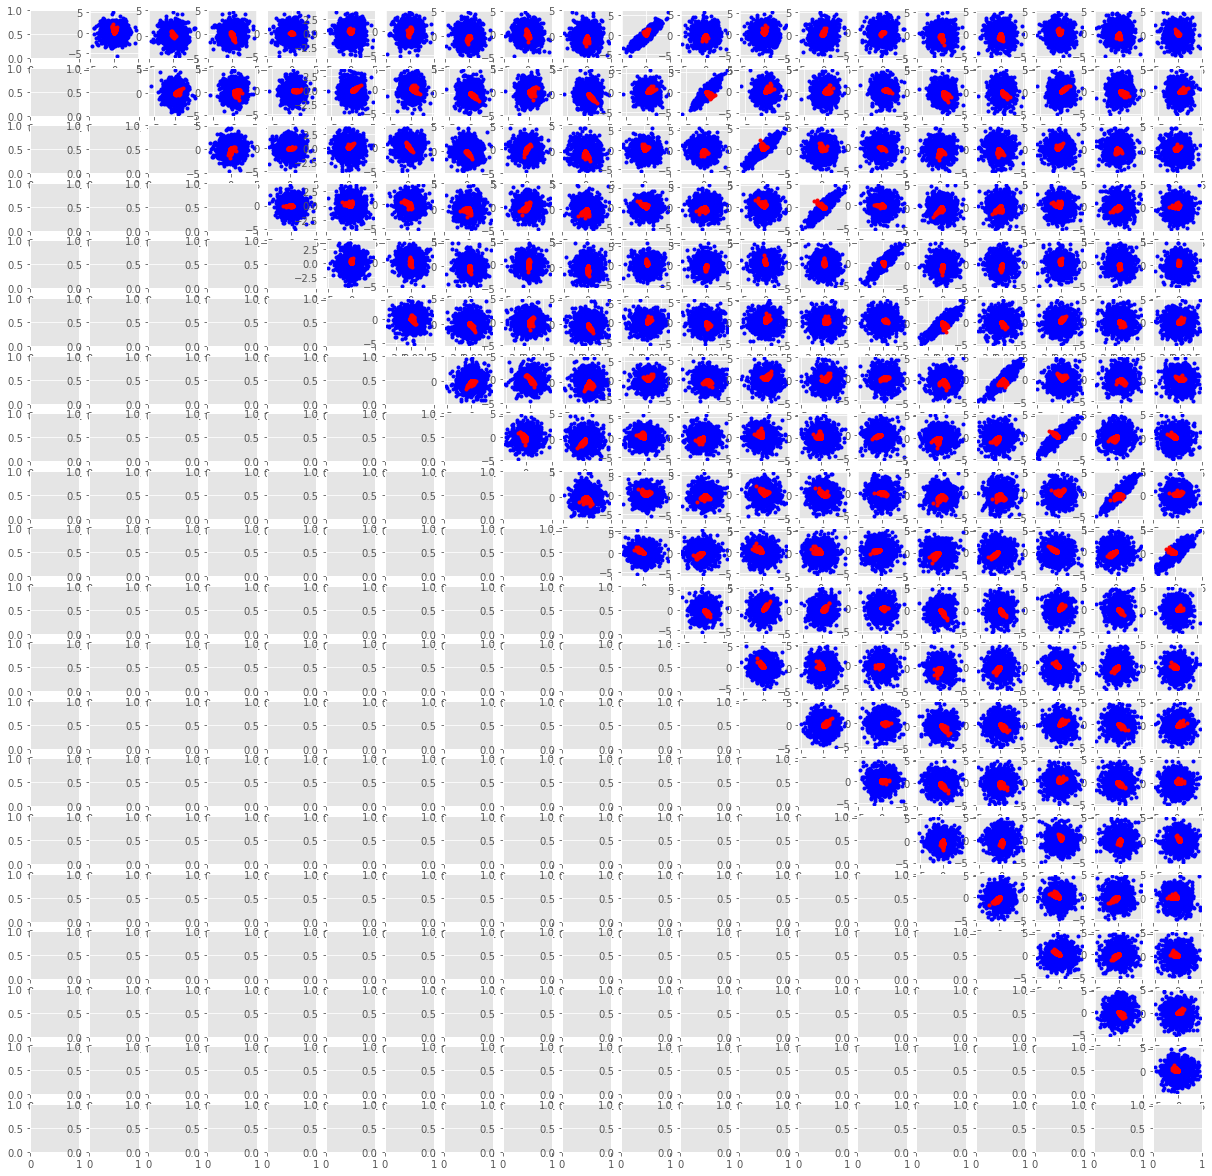

In [5]:

# Generate reconstructed images

cases = 5000
data=x_test
sample = autoencoder_M.predict(data[:cases,:])

# Plot some of the original and reconstructed images
n = dim*2  # Number of images to plot
#plt.figure(figsize=(5, 5))
#plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1], s=1)

#corr=np.array([n+1,n+1])
corr_sample = np.zeros((n+1, n+1), dtype=np.float64)
corr_data = np.zeros((n+1, n+1), dtype=np.float64)

fig, axs = plt.subplots(n, n,figsize=(n+1,n+1))
for i in range(0,n,1):
    for j in range(i+1,n,1):
        axs[i,j].plot(data[:cases,i],data[:cases,j],'b.')    
        axs[i,j].plot(sample[:,i],sample[:,j],'r.')           
        corrr = stats.spearmanr(sample[:,i], sample[:,j])
        corr_sample[i][j]=corrr[0]
        corrr = stats.spearmanr(data[:,i], data[:,j])
        corr_data[i][j]=corrr[0]
        #axs[i,j].plot(u[:,i],u[:,j],'r.')    
        #axs[i,j].set_title(str(i+1)+","+str(j+1))
#for i in range(0,n,1):
        #print(i+1,min(data[:cases,i]),min(sample[:,i]))        
        #print(i+1,max(data[:cases,i]),max(sample[:,i]))




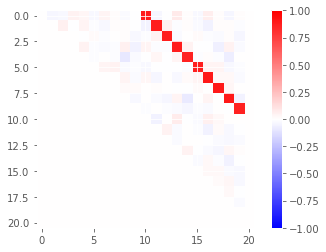

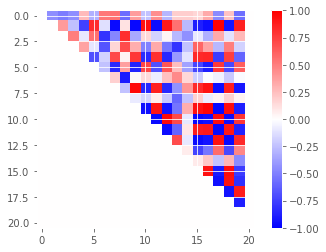

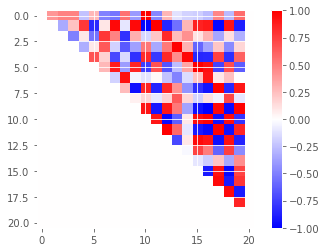

In [6]:

colors = [(0, 0, 1), (1, 1, 1), (1, 0, 0)]
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)
fig, axs = plt.subplots(1,1)
plt.imshow(corr_data, cmap, vmin=-1, vmax=1)
plt.colorbar()
plt.show()
fig, axs = plt.subplots(1,1)
plt.imshow(corr_sample, cmap, vmin=-1, vmax=1)
plt.colorbar()
plt.show()
fig, axs = plt.subplots(1,1)
plt.imshow((corr_data-corr_sample), cmap, vmin=-1, vmax=1)
plt.colorbar()
plt.show()

In [7]:
test_loss = autoencoder_M.evaluate(x_test, x_test)
print(f'Test loss: {test_loss:.4f}')

32/32 [==============================] - 0s 2ms/step - loss: 97.4789
Test loss: 97.4789


In [8]:
if 1==2:
# Encode the test dataset to get the latent vectors
    z_mean, z_log_var, encoded_imgs = encoder.predict(x_test)

# Get the labels for each image
#abels = y_test

# Use t-SNE to project the latent vectors to 2D space
    tsne = TSNE(n_components=2, random_state=42)
    encoded_imgs_tsne = tsne.fit_transform(encoded_imgs)

# Plot the t-SNE projection
    fig = plt.figure(figsize=(8, 8))
    plt.scatter(encoded_imgs_tsne[:, 0], encoded_imgs_tsne[:, 1], cmap='viridis', s=2)
    plt.colorbar()
    plt.axis('equal')
    plt.show()


20


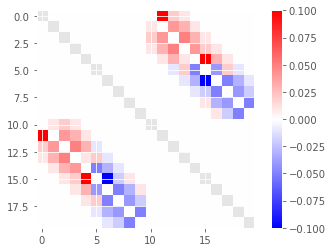

In [9]:
# Define covariance matrix
mat1 = np.eye(10)
mat2 = np.array([[0, 0.1, 0.02, 0.01, 0, 0, 0, 0, 0, 0],
                       [0.01, 0, 0.04, 0.03, 0.01, 0, 0, 0, 0, 0],
                       [0.02, 0.04, 0, 0.05, 0.03, 0.01, 0, 0, 0, 0],
                       [0.01, 0.03, 0.05, 0, 0.04, 0.02, 0.01, 0, 0, 0],
                       [0, 0.01, 0.03, 0.01, 0, 0.1, 0.03, 0.01, 0, 0],
                       [0, 0, -0.01, 0.02, -0.05, 0, -0.04, 0.02, -0.01, 0],
                       [0, 0, 0, -0.01, -0.03, -0.4, 0, -0.05, -0.03, -0.01],
                       [0, 0, 0, 0, -0.01, -0.02, -0.05, 0, -0.04, -0.02],
                       [0, 0, 0, 0, 0, 0.01, -0.03, -0.04, 0, -0.05],
                       [0, 0, 0, 0, 0, 0, 0.01, -0.02, -0.05, 0]])
mat4 = np.eye(10)
mat3 = np.transpose(mat2)

# Concatenate the four matrices into a single 20x20 matrix
top_row = np.concatenate((mat1, mat2), axis=1)
bottom_row = np.concatenate((mat3, mat4), axis=1)
cov_matrix = np.concatenate((top_row, bottom_row), axis=0)

# Generate random data with the given covariance matrix
mean = np.zeros(20) # Mean vector of all zeros
data2 = np.random.multivariate_normal(mean, cov_matrix, size=7000)





n=data2.shape[1]
print(n)
corr_data = np.zeros((n+1, n+1), dtype=np.float64)

#fig, axs = plt.subplots(n, n,figsize=(n+1,n+1))
for i in range(0,n,1):
    for j in range(i+1,n,1):
#        axs[i,j].plot(data[:cases,i],data[:cases,j],'b.')    
#        axs[i,j].plot(sample[:,i],sample[:,j],'r.')           
        corrr = stats.spearmanr(data2[:,i], data2[:,j])
        corr_data[i][j]=corrr[0]
        #axs[i,j].plot(u[:,i],u[:,j],'r.')    
        #axs[i,j].set_title(str(i+1)+","+str(j+1))
#for i in range(0,n,1):
        #print(i+1,min(data[:cases,i]),min(sample[:,i]))        
        #print(i+1,max(data[:cases,i]),max(sample[:,i]))


colors = [(0, 0, 1), (1, 1, 1), (1, 0, 0)]
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)
fig, axs = plt.subplots(1,1)
np.fill_diagonal(cov_matrix, np.nan)

plt.imshow(cov_matrix, cmap, vmin=-0.1, vmax=0.1)
plt.colorbar()
plt.show()

In [10]:

x_train= data2[:6000,:]
x_test=  data2[6000:,:]


# Train the model
autoencoder_M.fit(x_train, x_train, epochs=2*2, batch_size=128*4, validation_data=(x_test, x_test), verbose=2)

# Call the autoencoder to get the reconstructed outputs and the mean and log variance of the latent variable distribution
x_pred = autoencoder_M(x_train)
z_mean, z_log_var, z = encoder(x_train)

# Compute the ELBO
recon_loss = np.mean(np.sum(np.square(x_train - x_pred), axis=-1))
kl_loss = np.mean(-0.5 * np.sum(1 + z_log_var - np.square(z_mean) - np.exp(z_log_var), axis=-1))
elbo = recon_loss + kl_loss

print("Reconstruction loss:", recon_loss)
print("KL divergence loss:", kl_loss)
print("ELBO:", elbo)

Epoch 1/4
12/12 - 0s - loss: 45.2704 - val_loss: 44.2704
Epoch 2/4
12/12 - 0s - loss: 44.3852 - val_loss: 43.5722
Epoch 3/4
12/12 - 0s - loss: 43.7419 - val_loss: 43.4824
Epoch 4/4
12/12 - 0s - loss: 43.2927 - val_loss: 43.1699

If you intended to run this layer in float32, you can safely ignore this warning. If in doubt, this warning is likely only an issue if you are porting a TensorFlow 1.X model to TensorFlow 2.

To change all layers to have dtype float64 by default, call `tf.keras.backend.set_floatx('float64')`. To change just this layer, pass dtype='float64' to the layer constructor. If you are the author of this layer, you can disable autocasting by passing autocast=False to the base Layer constructor.

Reconstruction loss: 20.720732
KL divergence loss: 1.6455234
ELBO: 22.366255


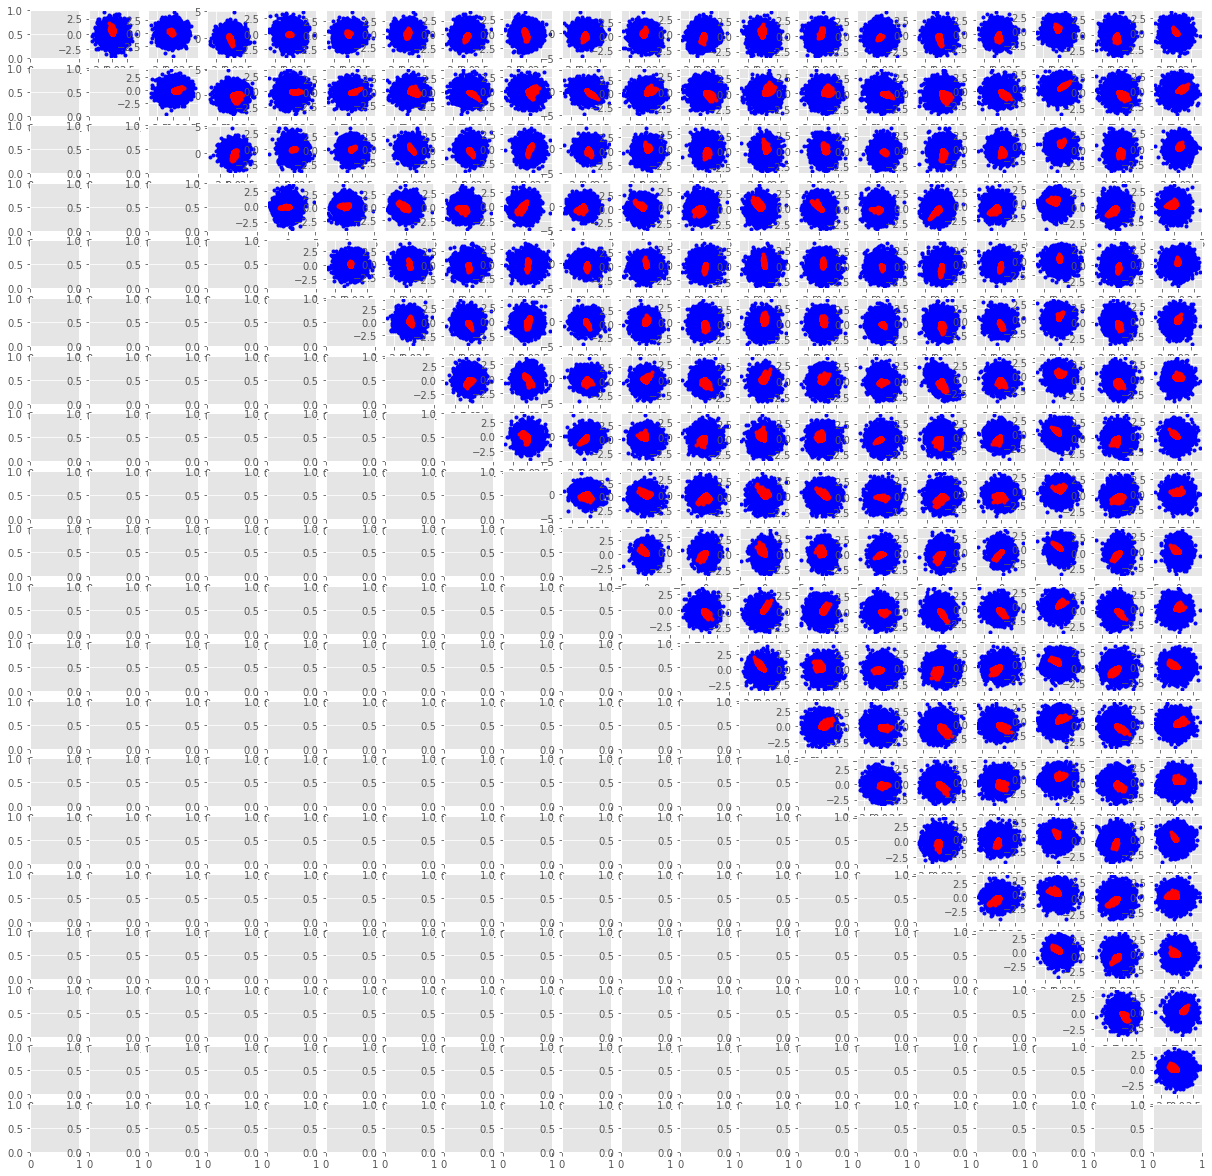

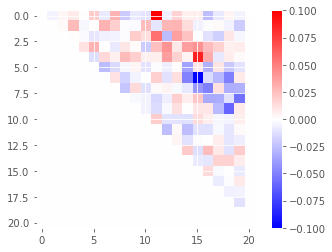

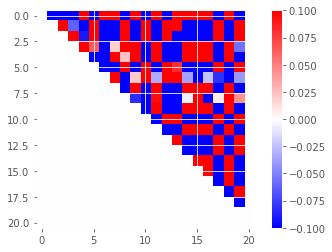

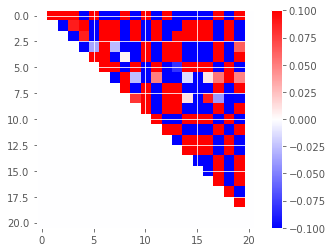

In [11]:

# Generate reconstructed images

cases = 5000
data=x_test
sample = autoencoder_M.predict(data2[:cases,:])

# Plot some of the original and reconstructed images
n = dim*2  # Number of images to plot
#plt.figure(figsize=(5, 5))
#plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1], s=1)

#corr=np.array([n+1,n+1])
corr_sample = np.zeros((n+1, n+1), dtype=np.float64)
corr_data = np.zeros((n+1, n+1), dtype=np.float64)

fig, axs = plt.subplots(n, n,figsize=(n+1,n+1))
for i in range(0,n,1):
    for j in range(i+1,n,1):
        axs[i,j].plot(data2[:cases,i],data2[:cases,j],'b.')    
        axs[i,j].plot(sample[:,i],sample[:,j],'r.')           
        corrr = stats.spearmanr(sample[:,i], sample[:,j])
        corr_sample[i][j]=corrr[0]
        corrr = stats.spearmanr(data2[:,i], data2[:,j])
        corr_data[i][j]=corrr[0]
        #axs[i,j].plot(u[:,i],u[:,j],'r.')    
        #axs[i,j].set_title(str(i+1)+","+str(j+1))
#for i in range(0,n,1):
        #print(i+1,min(data[:cases,i]),min(sample[:,i]))        
        #print(i+1,max(data[:cases,i]),max(sample[:,i]))


colors = [(0, 0, 1), (1, 1, 1), (1, 0, 0)]
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)
fig, axs = plt.subplots(1,1)
plt.imshow(corr_data, cmap, vmin=-0.1, vmax=0.1)
plt.colorbar()
plt.show()
fig, axs = plt.subplots(1,1)
plt.imshow(corr_sample, cmap, vmin=-0.1, vmax=0.1)
plt.colorbar()
plt.show()
fig, axs = plt.subplots(1,1)
plt.imshow((corr_data-corr_sample), cmap, vmin=-0.1, vmax=0.1)
plt.colorbar()
plt.show()

In [12]:

vine_type = "d-vine"      
method = 'matrix' #'matrix' 'optimal'
families = "kercop"
knots = 50
x = np.array(data2[:5000,:],np.float32)

vine_total_dim = x.shape[1]
r_matrix, ind_vine, nodes, E = random_r_matrix_gen(vine_total_dim)
margin_vine = []
for i in range(0,vine_total_dim,1):
    mar_p = margin_obj('norm', [0,1], True)
    margin_vine.append(mar_p) 
if vine_type == "r-vine":
    vine = vine_obj_bin(vine_type, families, vine_total_dim, margin_vine, knots, method, r_matrix)
else:
    vine = vine_obj_bin(vine_type, families, vine_total_dim, margin_vine, knots)

param = False
binning = False
n_bins = 3
parallel = True        

print(x.shape)

#exc = x.shape[0]  #tf.math.floormod(tf.shape(x)[0],5)
#x = x[:x.shape[0]-exc,:]
sort_n = 'rand'
e = prep_cop(x, vine, sort_n)
vine_depth_fit = 2*dim+1
gen_dict = {'parallel':parallel, 'binning':binning, 'param':param, 'vine_depth':vine_depth_fit, 'fitted':False}  #vine_depth
par_dict = {'param_families':["ind","gaussian"]}  #["ind","gaussian","student","clayton","claytonrot90"]
npc_dict = {'opt_method':'LL1','batch_paral':3}
bin_dict = {'n_bin':n_bins}
save_vine = False

print(vine_depth_fit)
print(x.shape)
print(sort_n)

vine.fit(x,gen_dict,npc_dict,par_dict,bin_dict)

nodes:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
edges:
['(1,2)', '(2,3)', '(3,4)', '(4,5)', '(5,6)', '(6,7)', '(7,8)', '(8,9)', '(9,10)', '(10,11)', '(11,12)', '(12,13)', '(13,14)', '(14,15)', '(15,16)', '(16,17)', '(17,18)', '(18,19)', '(19,20)']
['(1,3|2)', '(2,4|3)', '(3,5|4)', '(4,6|5)', '(5,7|6)', '(6,8|7)', '(7,9|8)', '(8,10|9)', '(9,11|10)', '(10,12|11)', '(11,13|12)', '(12,14|13)', '(13,15|14)', '(14,16|15)', '(15,17|16)', '(16,18|17)', '(17,19|18)', '(18,20|19)']
['(1,4|2,3)', '(2,5|3,4)', '(3,6|4,5)', '(4,7|5,6)', '(5,8|6,7)', '(6,9|7,8)', '(7,10|8,9)', '(8,11|9,10)', '(9,12|10,11)', '(10,13|11,12)', '(11,14|12,13)', '(12,15|13,14)', '(13,16|14,15)', '(14,17|15,16)', '(15,18|16,17)', '(16,19|17,18)', '(17,20|18,19)']
['(1,5|2,3,4)', '(2,6|3,4,5)', '(3,7|4,5,6)', '(4,8|5,6,7)', '(5,9|6,7,8)', '(6,10|7,8,9)', '(7,11|8,9,10)', '(8,12|9,10,11)', '(9,13|10,11,12)', '(10,14|11,12,13)', '(11,15|12,13,14)', '(12,16|13,14,15)', '(13,17|14,15,16)', '(14,18|15,16,17

time_fit: 5.005768016497825
time_fit: 2.244567134374492
time_fit: 3.5794309122635752
time_fit: 0.6876095266829765
time_fit: 1.6986967218978748
time_fit: 3.1527273971452274
time_fit: 3.1492928394355033
time_fit: 0.4238499892689447
time_fit: 2.4280848654886142
time_fit: 2.0644634320071305
time_fit: 2.412741954046254
time_fit: 3.1407845174294096
time_fit: 1.4926512533554046
time_fit: 2.0986189606745995
time_fit: 0.5898670905171741
time_fit: 1.9531591274568711
time_fit: 2.8671365518185326
time_fit: 1.5016015701546053
time_fit: 0.5906714526107635
time_fit: 2.2554331766703797
time_fit: 1.7923800222085902
time_fit: 2.4050529242885546
time_fit: 1.363600904518563
time_fit: 1.8409123568804944
time_fit: 1.2248064523152493
time_fit: 0.9797413350669331
time_fit: 2.091877684706219
time_fit: 2.3140573628991774
time_fit: 1.0966478691869384
time_fit: 0.5911871650435501
time_fit: 1.493125907862293
time_fit: 0.8636307648282582
time_fit: 1.8474931336839973
time_fit: 1.1816592378777955
time_fit: 1.09999315

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import sys
from classes.objects import *
from vine_tree.tree_op import *

from scipy import stats
import pickle
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
###########

from param.generate_rvine import *
from param.margin_fit import *
from param.margin_op import *
from param.copula_fit import *
from param.cond_copula import *
from pre_proc.preparation import prep_cop
from pred.prediction import*
from sampling.vine_sample import *
from info.info_estimation import vine_entropy


cases = 2000
sample1, u1, pf1, ps1 = vine_copula_sample(vine,cases)

fig, axs = plt.subplots(vine.n_cop, vine.n_cop,figsize=(2*dim+1,2*dim+1))
for i in range(0,vine.n_cop,1):
    for j in range(i+1,vine.n_cop,1):
        axs[i,j].plot(data[:cases,i],data[:cases,j],'b.')    
        axs[i,j].plot(sample[:,i],sample[:,j],'r.')    
        #axs[i,j].plot(u[:,i],u[:,j],'r.')    
        #axs[i,j].set_title(str(i+1)+","+str(j+1))
for i in range(0,vine.n_cop,1):
        print(i+1,min(data[:cases,i]),min(sample[:,i]))        
        print(i+1,max(data[:cases,i]),max(sample[:,i]))

20
[[0.05633338 0.5553545  0.6841656  ... 0.03784427 0.67619854 0.05712707]
 [0.17951465 0.0479763  0.9452082  ... 0.02149303 0.51620436 0.21996456]
 [0.9177458  0.48470166 0.97163606 ... 0.03346089 0.05834296 0.01023403]
 ...
 [0.7466812  0.94608885 0.760683   ... 0.08382923 0.57617986 0.07917167]
 [0.40424067 0.5054558  0.46864256 ... 0.31057525 0.79153657 0.01356788]
 [0.3206187  0.937721   0.79353744 ... 0.7793882  0.03573352 0.04766551]]
(2000, 20)
20
(2000,)
(2000,)
(2000,)


ValueError: could not broadcast input array from shape (4999) into shape (5000)

In [14]:
print(vine_total_dim)

20
